In [1]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

In [2]:
#data
housing = fetch_california_housing()
data = fetch_california_housing(as_frame=True).frame

In [3]:
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
data.shape

(20640, 9)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
#missing values
print("Missing Values:\n",data.isnull().sum())

Missing Values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


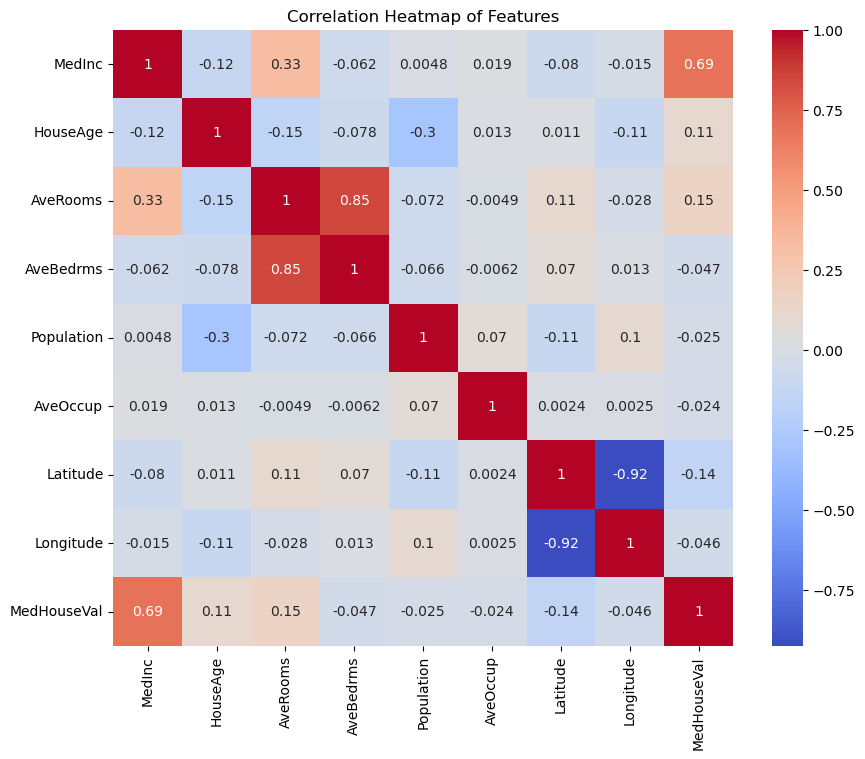

In [8]:
#1. Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap of Features")
plt.show()

In [28]:
#Features & Target
X = data.drop('MedHouseVal', axis=1)
y = data['MedHouseVal']

#Train-Test
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [29]:
#Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [30]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)
print(X_train_scaled)

(14448, 8)
(6192, 8)
[[ 0.13350629  0.50935748  0.18106017 ... -0.01082519 -0.80568191
   0.78093406]
 [-0.53221805 -0.67987313 -0.42262953 ... -0.08931585 -1.33947268
   1.24526986]
 [ 0.1709897  -0.36274497  0.07312833 ... -0.04480037 -0.49664515
  -0.27755183]
 ...
 [-0.49478713  0.58863952 -0.59156984 ...  0.01720102 -0.75885816
   0.60119118]
 [ 0.96717102 -1.07628333  0.39014889 ...  0.00482125  0.90338501
  -1.18625198]
 [-0.68320166  1.85715216 -0.82965604 ... -0.0816717   0.99235014
  -1.41592345]]


In [31]:
#model
model=LinearRegression()
model.fit(X_train_scaled,y_train)

#Prediction
y_pred=model.predict(X_test_scaled)

#Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nIntercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("Mean Squared Error:", mse)
print("R² Score:", r2)


Intercept: 2.0692396089424165
Coefficients: [ 8.49221760e-01  1.22119309e-01 -2.99558449e-01  3.48409673e-01
 -8.84488134e-04 -4.16980388e-02 -8.93855649e-01 -8.68616688e-01]
Mean Squared Error: 0.5305677824766755
R² Score: 0.5957702326061662


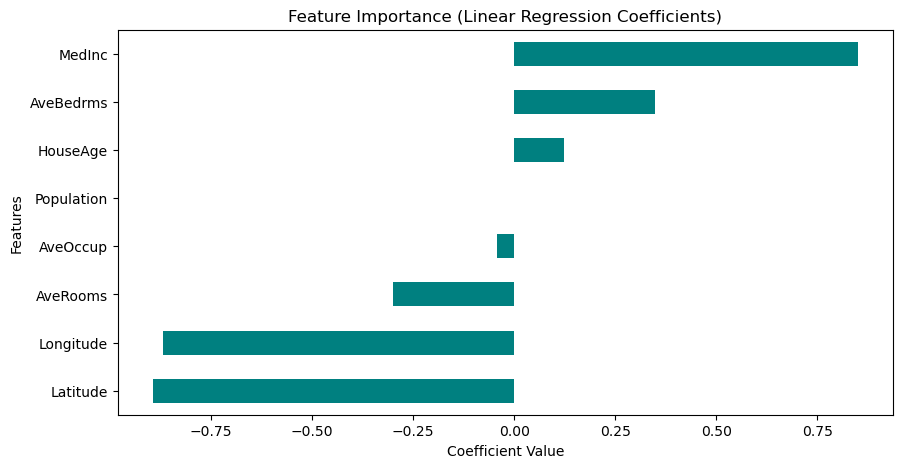

In [32]:
#Feature Importance
feature_importance = pd.Series(model.coef_, index=X.columns)
plt.figure(figsize=(10,5))
feature_importance.sort_values().plot(kind='barh', color='teal')
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.show()

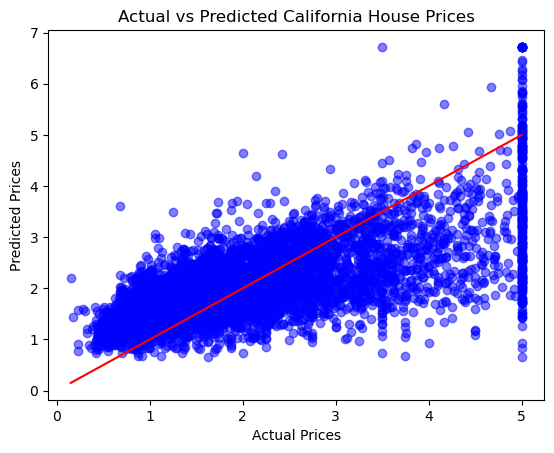

In [24]:
# 10. Visualization: Predicted vs Actual
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted California House Prices')
plt.show()

In [36]:
# Example new data
sample_input = pd.DataFrame({
    'MedInc': [8],
    'HouseAge': [20],
    'AveRooms': [5],
    'AveBedrms': [1],
    'Population': [1000],
    'AveOccup': [3],
    'Latitude': [34],
    'Longitude': [-118]
})

# Scale the input
sample_input_scaled = scaler.transform(sample_input)

# Predict
predicted_value = model.predict(sample_input_scaled)

print("Predicted Median House Value:", predicted_value[0] * 100000)

Predicted Median House Value: 380614.6506709988
